# CIFAR 10 Exercise

We explore 3 different techniques which will later be utilized in anomaly detection algorithms
1. CNNs
2. PCA
3. Autoencoders

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision 
import torchvision.transforms as transforms
import torchsummary as summary
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

In [2]:
device = torch.device("cpu")
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_built() and torch.backends.mps.is_available():
    device = torch.device("mps")
print(device)

cpu


## 1. Obtaining and prepocessing data

ToTensor - converts values to 0 and 1, and chages shape from 32x32x3 to 3x32x32.
Normalize - first tuple is the mean, 1 value for each channel. second tuple is the sd. new_val = (old_val - 0.5)/0.5. Therefore this normalizes value to be between -1 and 1 which is what CNN prefer.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

Now we can load in the data, and pass in our transform

In [4]:
train_set = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, download = True, transform=transform)

Here we pass the images in a DataLoader(). This is a tool that helps feed the images into our model in chunks (in this case 4). We shuffle the training data which prevents the model from learning the order, and help it to generalize better.

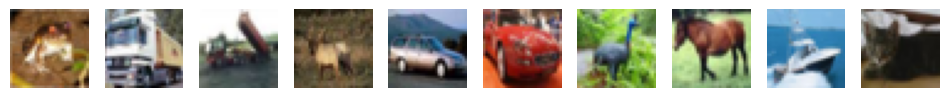

In [5]:
train_loader = torch.utils.data.DataLoader(train_set, batch_size=4, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=4, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

fig, axes = plt.subplots(1, 10, figsize=(12, 3))
for i in range(10):
    image = train_loader.dataset[i][0].permute(1, 2, 0)
    denormalized_image = image /2 + 0.5
    axes[i].imshow(denormalized_image)
    axes[i].axis('off')
plt.show()

## 2. Create our CNN, and construct our forward path.

In [6]:
class ConvNeuraNet(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv2 = nn.Conv2d(64, 128, 3)

        self.pool = nn.MaxPool2d(2, stride=2)

        self.fc1 = nn.Linear(128 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.log_softmax(self.fc3(x), dim=1)
        return x
    

net = ConvNeuraNet()
net.to(device)

ConvNeuraNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=4608, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

## 3. Train our model

In [7]:
loss_function = nn.NLLLoss() # this calculates the average loss per batch.
optimizer = optim.Adam(net.parameters(), lr=0.001)

epochs = 10

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch in range(epochs):

    net.train()

    #rtl: running train loss
    avg_batch_rtl = 0.0
    ttl_batch_rtl = 0.0

    for i, data in enumerate(train_loader):
        # i: batch index
        # data: (image_batch, label_batch)
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        avg_batch_rtl += loss.item()
        ttl_batch_rtl += loss.item() * inputs.size(0)
        
        if i % 2000 == 1999:
            print(f'[{epoch + 1}/{epochs}, {i + 1:5d}] loss: {avg_batch_rtl / 2000:.3f}')
            avg_batch_rtl = 0.0
    avg_epoch_loss = ttl_batch_rtl / len(train_loader.dataset)
    train_loss_per_epoch.append(avg_epoch_loss)

    net.eval()

    # rvl: running validation loss
    ttl_batch_rvl = 0.0
    with torch.no_grad():
        for i,data in enumerate(test_loader):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = net(inputs)
            loss = loss_function(outputs, labels)

            ttl_batch_rvl += loss.item() * inputs.size(0)

    avg_val_epoch_loss = ttl_batch_rvl / len(test_loader.dataset)
    val_loss_per_epoch.append(avg_val_epoch_loss)

    print(
        f'Epoch {epoch+1}/{epochs}, '
        f'Train loss: {avg_epoch_loss:.3f}, '
        f'Validation loss: {avg_val_epoch_loss:.3f}'
    )
print('finished training')

[1/10,  2000] loss: 1.793
[1/10,  4000] loss: 1.499
[1/10,  6000] loss: 1.398
[1/10,  8000] loss: 1.301
[1/10, 10000] loss: 1.276
[1/10, 12000] loss: 1.196
Epoch 1/10, Train loss: 1.400, Validation loss: 1.185
[2/10,  2000] loss: 1.114
[2/10,  4000] loss: 1.112
[2/10,  6000] loss: 1.087
[2/10,  8000] loss: 1.069
[2/10, 10000] loss: 1.052
[2/10, 12000] loss: 1.057
Epoch 2/10, Train loss: 1.080, Validation loss: 1.026
[3/10,  2000] loss: 0.964
[3/10,  4000] loss: 0.976
[3/10,  6000] loss: 0.964
[3/10,  8000] loss: 0.969
[3/10, 10000] loss: 0.974
[3/10, 12000] loss: 0.961
Epoch 3/10, Train loss: 0.967, Validation loss: 0.986
[4/10,  2000] loss: 0.876
[4/10,  4000] loss: 0.894
[4/10,  6000] loss: 0.902
[4/10,  8000] loss: 0.891
[4/10, 10000] loss: 0.908
[4/10, 12000] loss: 0.898
Epoch 4/10, Train loss: 0.894, Validation loss: 0.945
[5/10,  2000] loss: 0.803
[5/10,  4000] loss: 0.837
[5/10,  6000] loss: 0.852
[5/10,  8000] loss: 0.846
[5/10, 10000] loss: 0.858
[5/10, 12000] loss: 0.865
Epoc

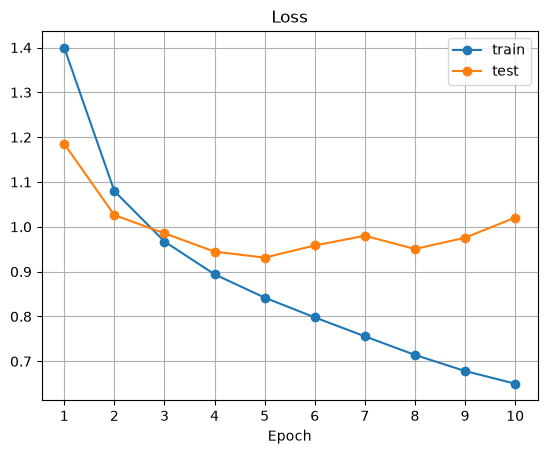

In [8]:
x_axis = np.arange(1,11)
plt.figure()
plt.plot(x_axis, train_loss_per_epoch, marker='o', label='train')
plt.plot(x_axis, val_loss_per_epoch, marker='o', label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.xticks(x_axis)
plt.legend()

## Adding droupout to deal with overfitting

In [11]:
class ConvNeuraNet_dropout(nn.Module):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

        self.conv1 = nn.Conv2d(3, 64, 3)
        self.conv2 = nn.Conv2d(64, 128, 3)

        self.pool = nn.MaxPool2d(2, stride=2)

        # Dropout layers
        self.dropout_2d = nn.Dropout2d(p=0.25)
        self.droptout_fc = nn.Dropout(p=0.5)

        self.fc1 = nn.Linear(128 * 6 * 6, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout_2d(x) # dropout layer after convolution layers

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.droptout_fc(x) # dropout layer after first neural layer

        x = F.relu(self.fc2(x))
        x = self.droptout_fc(x) # dropout layer after second neural layer

        x = F.log_softmax(self.fc3(x), dim=1)
        return x
    
net = ConvNeuraNet_dropout()
net.to(device)

ConvNeuraNet_dropout(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout_2d): Dropout2d(p=0.25, inplace=False)
  (droptout_fc): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=4608, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Retrain our model

In [12]:
optimizer = optim.Adam(net.parameters(), lr=0.001)

train_loss_per_epoch = []
val_loss_per_epoch = []

for epoch in range(epochs):

    net.train()

    #rtl: running train loss
    avg_batch_rtl = 0.0
    ttl_batch_rtl = 0.0

    for i, data in enumerate(train_loader):
        # i: batch index
        # data: (image_batch, label_batch)
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = loss_function(outputs, labels)

        loss.backward()
        optimizer.step()

        avg_batch_rtl += loss.item()
        ttl_batch_rtl += loss.item() * inputs.size(0)
        
        if i % 2000 == 1999:
            print(f'[{epoch + 1}/{epochs}, {i + 1:5d}] loss: {avg_batch_rtl / 2000:.3f}')
            avg_batch_rtl = 0.0
    avg_epoch_loss = ttl_batch_rtl / len(train_loader.dataset)
    train_loss_per_epoch.append(avg_epoch_loss)

    net.eval()

    # rvl: running validation loss
    ttl_batch_rvl = 0.0
    with torch.no_grad():
        for i,data in enumerate(test_loader):
            inputs, labels = data[0].to(device), data[1].to(device)

            outputs = net(inputs)
            loss = loss_function(outputs, labels)

            ttl_batch_rvl += loss.item() * inputs.size(0)

    avg_val_epoch_loss = ttl_batch_rvl / len(test_loader.dataset)
    val_loss_per_epoch.append(avg_val_epoch_loss)

    print(
        f'Epoch {epoch+1}/{epochs}, '
        f'Train loss: {avg_epoch_loss:.3f}, '
        f'Validation loss: {avg_val_epoch_loss:.3f}'
    )
print('finished training')

[1/10,  2000] loss: 2.079
[1/10,  4000] loss: 1.867
[1/10,  6000] loss: 1.800
[1/10,  8000] loss: 1.720
[1/10, 10000] loss: 1.662
[1/10, 12000] loss: 1.650
Epoch 1/10, Train loss: 1.788, Validation loss: 1.485
[2/10,  2000] loss: 1.594
[2/10,  4000] loss: 1.563
[2/10,  6000] loss: 1.546
[2/10,  8000] loss: 1.548
[2/10, 10000] loss: 1.509
[2/10, 12000] loss: 1.527
Epoch 2/10, Train loss: 1.545, Validation loss: 1.264
[3/10,  2000] loss: 1.483
[3/10,  4000] loss: 1.461
[3/10,  6000] loss: 1.447
[3/10,  8000] loss: 1.455
[3/10, 10000] loss: 1.446
[3/10, 12000] loss: 1.421
Epoch 3/10, Train loss: 1.453, Validation loss: 1.216
[4/10,  2000] loss: 1.400
[4/10,  4000] loss: 1.397
[4/10,  6000] loss: 1.422
[4/10,  8000] loss: 1.381
[4/10, 10000] loss: 1.388
[4/10, 12000] loss: 1.377
Epoch 4/10, Train loss: 1.396, Validation loss: 1.197
[5/10,  2000] loss: 1.369
[5/10,  4000] loss: 1.370
[5/10,  6000] loss: 1.343
[5/10,  8000] loss: 1.347
[5/10, 10000] loss: 1.355
[5/10, 12000] loss: 1.346
Epoc

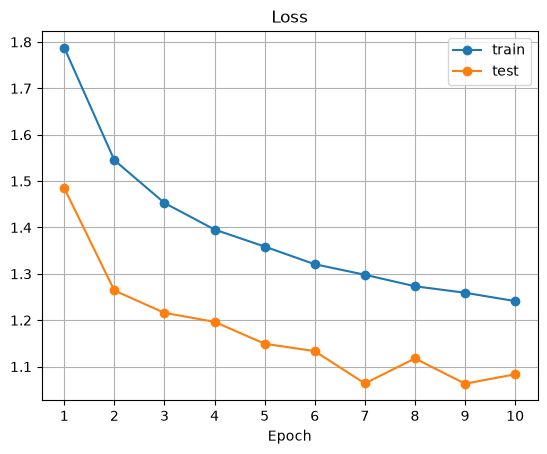

In [13]:
x_axis = np.arange(1,11)
plt.figure()
plt.plot(x_axis, train_loss_per_epoch, marker='o', label='train')
plt.plot(x_axis, val_loss_per_epoch, marker='o', label='test')
plt.title('Loss')
plt.xlabel('Epoch')
plt.grid()
plt.xticks(x_axis)
plt.legend()